In [15]:
import pandas as pd

In [16]:
df = pd.read_csv("https://raw.githubusercontent.com/holleland/TECH3/refs/heads/main/data/Default.csv", sep = ";")

In [17]:
income = df['income']
income

0       44361.62507
1       12106.13470
2       31767.13895
3       35704.49394
4       38463.49588
           ...     
9995    52992.37891
9996    19660.72177
9997    58636.15698
9998    36669.11236
9999    16862.95232
Name: income, Length: 10000, dtype: float64

In [18]:
income.mean()

33516.98187595744

In [19]:
income.median()

34552.6448

In [20]:
income.std()

13336.639562731909

In [21]:
df['default'].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

In [22]:
df['default'].value_counts()/len()

TypeError: len() takes exactly one argument (0 given)

In [23]:
pip install nhanes

Note: you may need to restart the kernel to use updated packages.


In [24]:
from nhanes.load import load_NHANES_data
nhanes_data = load_NHANES_data()

In [25]:
nhanes_data.groupby('Gender')['StandingHeightCm'].mean()

Gender
Female    151.597032
Male      161.853342
Name: StandingHeightCm, dtype: float64

In [26]:
df.groupby('student')[['income']].describe()

income                                                         \
          count          mean           std          min           25%   
student                                                                  
No       7056.0  40011.952857  10010.288665  8017.638591  33417.480950   
Yes      2944.0  17950.230775   4533.007954   771.967729  14886.848738   

                                                 
                 50%           75%          max  
student                                          
No       39893.28740  46840.569767  73554.23350  
Yes      17994.02289  20985.983402  33003.42295

In [28]:
tab = df.loc[df['student'] == 'Yes', 'default'].value_counts()

In [29]:
tab/tab.sum()

default
No     0.956861
Yes    0.043139
Name: count, dtype: float64

For people with income above the median, what i the default rate

In [30]:
med = df['income'].median()

In [32]:
tab2 = df.loc[df['income'] > med, "default"].value_counts()

In [33]:
tab2/tab2.sum()

default
No     0.969
Yes    0.031
Name: count, dtype: float64

In [34]:
tab3 = df.loc[df['income'] > med, "student"].value_counts()

In [35]:
tab3/tab3.sum()

student
No    1.0
Name: count, dtype: float64

Visualization in Python

In [36]:
import matplotlib.pyplot as plt 

In [37]:
import seaborn as sns

<Axes: xlabel='income', ylabel='Count'>

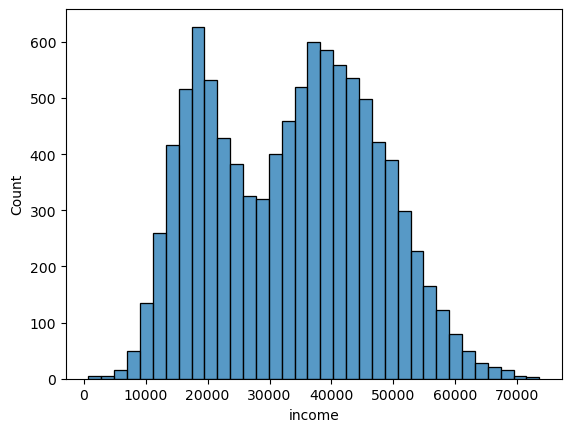

In [38]:
sns.histplot(x= 'income', data = df)

<Axes: xlabel='income', ylabel='Count'>

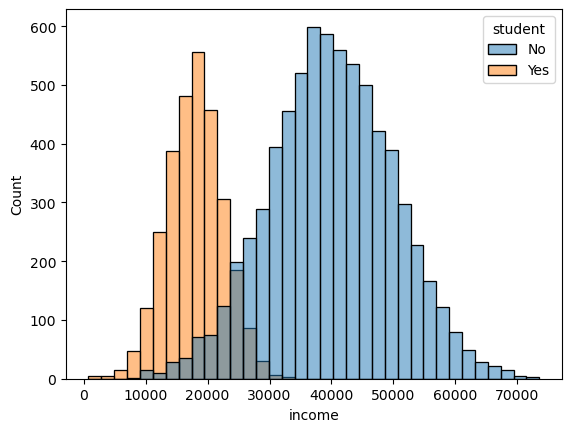

In [39]:
sns.histplot(x= 'income', data = df, hue = 'student')

<Axes: xlabel='default', ylabel='income'>

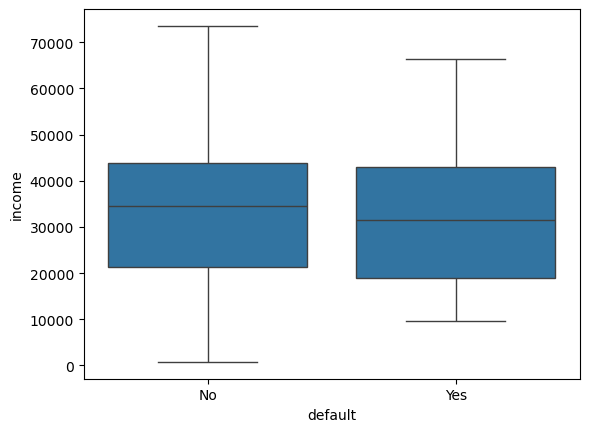

In [40]:
sns.boxplot(y='income', x = "default", data = df)

<Axes: xlabel='default', ylabel='income'>

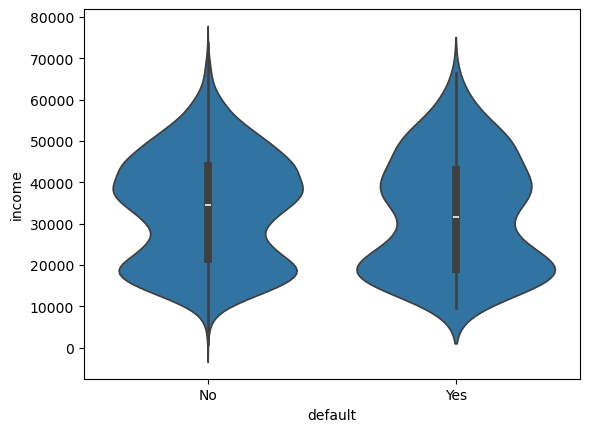

In [41]:
sns.violinplot(y='income', x = "default", data = df)

<Axes: xlabel='income', ylabel='balance'>

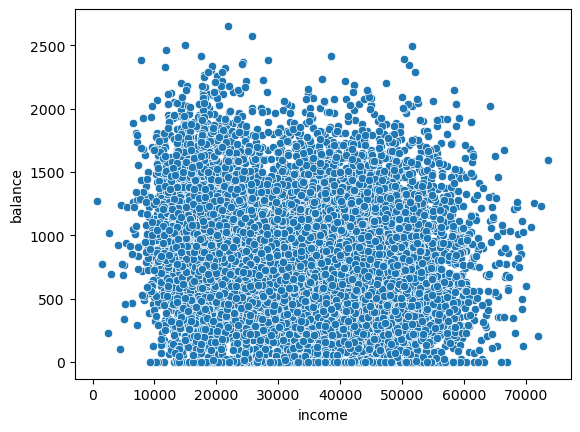

In [44]:
sns.scatterplot(x='income', y= "balance", data = df)

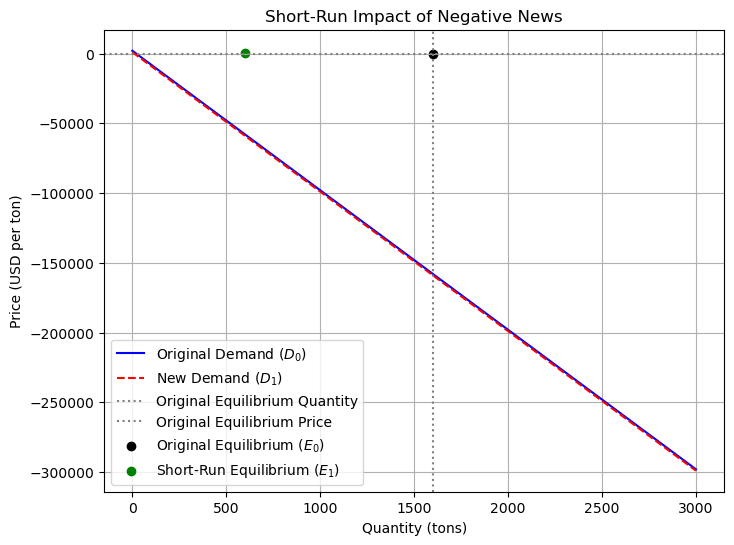

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Define the initial equilibrium values
P0 = 4  # Original equilibrium price
Q0 = 1600  # Original equilibrium quantity

# Define the new demand curve after negative news
def demand_curve(P):
    return 2000 - 100 * P  # Original demand curve
def new_demand_curve(P):
    return 1000 - 100 * P  # New demand curve after negative news

# Define the supply curve (short-run, fixed number of firms)
def supply_curve(Q):
    return Q  # Short-run supply curve (simplified for illustration)

# Define the long-run supply curve (upward-sloping)
def long_run_supply_curve(Q):
    return 2 + 0.002 * Q  # Long-run supply curve (upward-sloping)

# Generate data for plotting
P_values = np.linspace(0, 10, 100)  # Price range
Q_values = np.linspace(0, 3000, 100)  # Quantity range

# Short-run impact of negative news
Q1 = new_demand_curve(P0)  # New quantity demanded at original price
P1 = (2000 - Q1) / 100  # New price after demand shift

# Long-run impact of negative news
P2 = 3  # New long-run equilibrium price (assumed)
Q2 = new_demand_curve(P2)  # New long-run equilibrium quantity

# Graph 1: Short-Run Impact of Negative News
plt.figure(figsize=(8, 6))
plt.plot(Q_values, [demand_curve(P) for P in Q_values], label="Original Demand ($D_0$)", color="blue")
plt.plot(Q_values, [new_demand_curve(P) for P in Q_values], label="New Demand ($D_1$)", color="red", linestyle="--")
plt.axvline(x=Q0, color="gray", linestyle=":", label="Original Equilibrium Quantity")
plt.axhline(y=P0, color="gray", linestyle=":", label="Original Equilibrium Price")
plt.scatter(Q0, P0, color="black", label="Original Equilibrium ($E_0$)")
plt.scatter(Q1, P1, color="green", label="Short-Run Equilibrium ($E_1$)")
plt.title("Short-Run Impact of Negative News")
plt.xlabel("Quantity (tons)")
plt.ylabel("Price (USD per ton)")
plt.legend()
plt.grid()
plt.show()

# Graph 2: Long-Run Impact of Negative News


# Graph 3: Long-Run Supply Curve


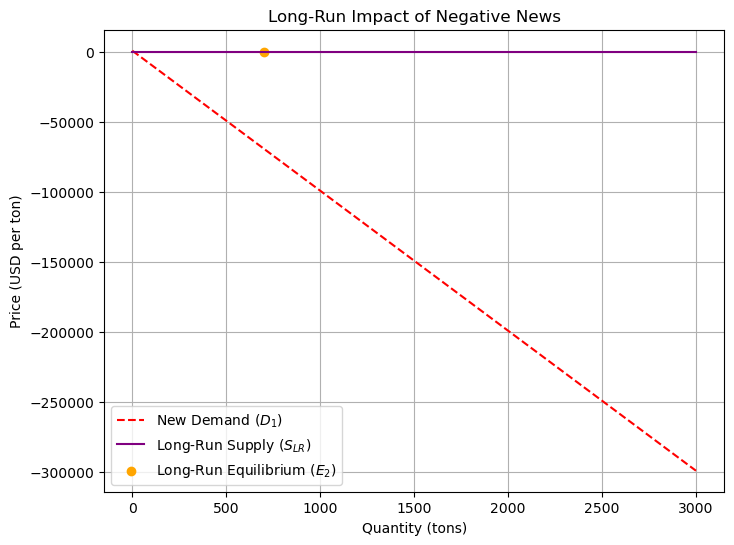

In [6]:
plt.figure(figsize=(8, 6))
plt.plot(Q_values, [new_demand_curve(P) for P in Q_values], label="New Demand ($D_1$)", color="red", linestyle="--")
plt.plot(Q_values, [long_run_supply_curve(Q) for Q in Q_values], label="Long-Run Supply ($S_{LR}$)", color="purple")
plt.scatter(Q2, P2, color="orange", label="Long-Run Equilibrium ($E_2$)")
plt.title("Long-Run Impact of Negative News")
plt.xlabel("Quantity (tons)")
plt.ylabel("Price (USD per ton)")
plt.legend()
plt.grid()
plt.show()

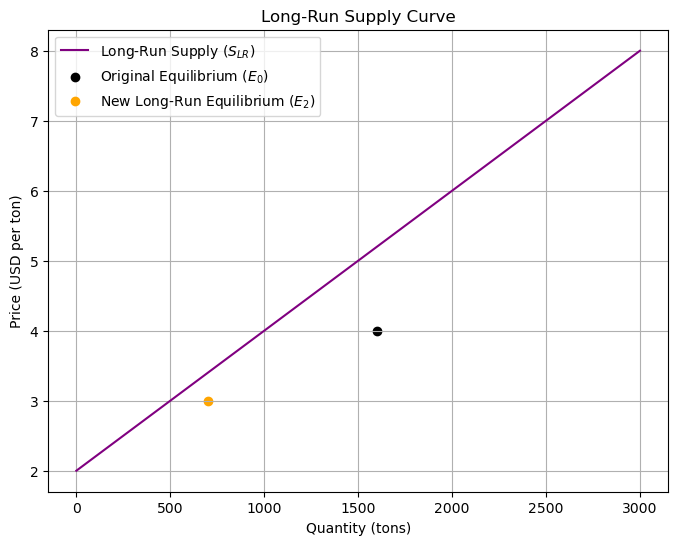

In [7]:
plt.figure(figsize=(8, 6))
plt.plot(Q_values, [long_run_supply_curve(Q) for Q in Q_values], label="Long-Run Supply ($S_{LR}$)", color="purple")
plt.scatter(Q0, P0, color="black", label="Original Equilibrium ($E_0$)")
plt.scatter(Q2, P2, color="orange", label="New Long-Run Equilibrium ($E_2$)")
plt.title("Long-Run Supply Curve")
plt.xlabel("Quantity (tons)")
plt.ylabel("Price (USD per ton)")
plt.legend()
plt.grid()
plt.show()